# MARI Water Breakthrough Prediction — POC
## Habib Rahi Limestone (HRL) Gas Reservoir

**Client:** Mari Energies  
**Field:** Mari Gas Field, Daharki, Sindh, Pakistan  
**Formation:** Habib Rahi Limestone (Eocene shallow carbonate), ~700 m TVD  
**Drive:** Natural depletion (no injection, no pressure support)  
**GWC:** 684 m TVD SS (field-wide)

### Objective
Predict P10/P50/P90 time-to-water-breakthrough for 4 dry horizontal wells:
- **M-123H**, **M-124H**, **M-125H**, **M-126H**

Using M-122H (broke through at month 12) as validation anchor.

### Event Definition
- **Primary:** Water-Gas Ratio (WGR) > 5 bbl/MMcf, sustained >= 3 consecutive months
- **Refinement:** Chloride concentration to distinguish formation water from condensation

### Model Ladder
1. Kaplan-Meier (field-wide & stratified)
2. Cox Proportional Hazards (interpretable baseline)
3. Weibull AFT (parametric, direct P10/P50/P90)
4. Random Survival Forest (non-linearity benchmark)
5. Physics-constrained Cox/AFT (sign constraints)

### Critical Rules
1. Always include 4 censored dry wells in the fit
2. Physics sign checks: higher Sw, closer-to-GWC, higher perm, higher drawdown -> shorter time
3. Report P10/P50/P90, not point estimates
4. Log every imputation decision
5. M-51 month-0 water: flag, exclude, document
6. Model must beat field-wide KM median baseline

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import datetime

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines import LogNormalAFTFitter, LogLogisticAFTFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import concordance_index

# Random Survival Forest
try:
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not installed. RSF will be skipped.')

import pickle

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_DIR = Path('new_data')
FIGURES_DIR = Path('figures_mari')
FIGURES_DIR.mkdir(exist_ok=True)

# Constants
GWC_TVD = 684  # m TVD SS, field-wide
WGR_THRESHOLD = 5  # bbl/MMcf
MIN_CONSECUTIVE_MONTHS = 3

print('Setup complete.')

Setup complete.


---
## 2. Data Loading

### 2.1 Pressure

In [2]:
# --- Production data (Sheet: PRESSURES -> actually contains production volumes) ---
prod_raw = pd.read_excel(
    DATA_DIR / 'STIXOR Sharing Data.xlsx',
    sheet_name='Pressures',
    header=1  # Header row is row 3 (0-indexed: 2)
)

# Standardise column names
prod_raw.columns = prod_raw.columns.str.strip()
print('Production sheet columns:', prod_raw.columns.tolist())
print(f'Shape: {prod_raw.shape}')
prod_raw.head(10)

Production sheet columns: ['Unnamed: 0', 'Date', 'Wells', 'Wellhead Flowing Pressure (WHFP)psig', 'Line Pressure psig']
Shape: (5354, 5)


,Unnamed: 0,Date,Wells,Wellhead Flowing Pressure (WHFP)psig,Line Pressure psig
0,NaN,1990-06-01,M-11-HRL,793.1,NaN
1,NaN,1990-08-01,M-11-HRL,NaN,NaN
2,NaN,1990-09-01,M-11-HRL,829.3,NaN
3,NaN,1990-10-01,M-11-HRL,NaN,NaN
4,NaN,1995-01-01,M-11-HRL,818.5,NaN
5,NaN,1995-02-01,M-11-HRL,810.4,NaN
6,NaN,1995-04-01,M-11-HRL,808.9,NaN
7,NaN,1995-05-01,M-11-HRL,778.2,NaN
8,NaN,1995-06-01,M-11-HRL,NaN,NaN
9,NaN,1995-07-01,M-11-HRL,NaN,NaN


In [3]:
prod = prod_raw.iloc[:,1:4]


In [4]:
prod.rename(columns={
    'Date': 'date',
    'Wells': 'well',
    'Wellhead Flowing Pressure (WHFP)psig': 'pressure'
}, inplace=True)

In [5]:
# Parse dates
prod['date'] = pd.to_datetime(prod['date'], errors='coerce')
prod = prod.dropna(subset=['date', 'well'])

# Standardise well names: strip whitespace
prod['well'] = prod['well'].str.strip()

print(f'Production data: {len(prod)} rows, {prod["well"].nunique()} wells')
print(f'Date range: {prod["date"].min()} to {prod["date"].max()}')
print(f'Wells: {sorted(prod["well"].unique())}')
prod.describe()

Production data: 5354 rows, 22 wells
Date range: 1990-06-01 00:00:00 to 2025-06-01 00:00:00
Wells: ['M-11-HRL', 'M-122H-HRL', 'M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL', 'M-126H-HRL', 'M-13-HRL', 'M-22-HRL', 'M-41-HRL', 'M-50-HRL', 'M-51-HRL', 'M-56-HRL', 'M-57-HRL', 'M-58-HRL', 'M-61-HRL', 'M-63-HRL', 'M-65-HRL', 'M-67-HRL', 'M-75-HRL', 'M-81-HRL', 'M-82-HRL', 'M-E-2-HRL']


,date,pressure
count,5354,5112.000000
mean,2012-04-11 06:22:43.615988224,526.144190
min,1990-06-01 00:00:00,51.300000
25%,2006-01-01 00:00:00,395.075000
50%,2012-08-01 00:00:00,545.900000
75%,2019-03-01 00:00:00,650.700000
max,2025-06-01 00:00:00,1026.200000
std,NaN,171.331957


### 2.2 Production Data

In [6]:
# --- Pressure / Rates sheet ---
rates_raw = pd.read_excel(
    DATA_DIR / 'STIXOR Sharing Data.xlsx',
    sheet_name='Rates',
    header=1
)
rates_raw.columns = rates_raw.columns.str.strip()
print('Rates sheet columns:', rates_raw.columns.tolist())

Rates sheet columns: ['Unnamed: 0', 'Date', 'Wells', 'CHOKE 1/64"', 'DAYS on production', 'Monthly Gas Produced MMcf (volume)', 'Monthly Water Produced bbl (volume)', 'Unnamed: 7', 'Notes', 'Unnamed: 9']


In [7]:
rates_raw

,Unnamed: 0,Date,Wells,"CHOKE 1/64""",DAYS on production,Monthly Gas Produced MMcf (volume),Monthly Water Produced bbl (volume),Unnamed: 7,Notes,Unnamed: 9
0,NaN,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00,NaN,1,The Gas Produced and Water Produced are the vo...
1,NaN,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70,NaN,2,The rates can be calculated suing the volume a...
2,NaN,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46,NaN,3,The fluid ratios can be estimated using the vo...
3,NaN,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10,NaN,4,The WHFP (well head flowing pressure) and line...
4,NaN,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6647,NaN,2025-02-01,M-E-2-HRL,128.0,24.0,122.895,NaN,NaN,NaN,NaN
6648,NaN,2025-03-01,M-E-2-HRL,128.0,27.0,163.161,NaN,NaN,NaN,NaN
6649,NaN,2025-04-01,M-E-2-HRL,128.0,30.0,141.786,NaN,NaN,NaN,NaN
6650,NaN,2025-05-01,M-E-2-HRL,128.0,31.0,143.860,NaN,NaN,NaN,NaN


In [8]:
rates = rates_raw.iloc[:,1:7]
rates

,Date,Wells,"CHOKE 1/64""",DAYS on production,Monthly Gas Produced MMcf (volume),Monthly Water Produced bbl (volume)
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46
3,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10
4,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08
...,...,...,...,...,...,...
6647,2025-02-01,M-E-2-HRL,128.0,24.0,122.895,NaN
6648,2025-03-01,M-E-2-HRL,128.0,27.0,163.161,NaN
6649,2025-04-01,M-E-2-HRL,128.0,30.0,141.786,NaN
6650,2025-05-01,M-E-2-HRL,128.0,31.0,143.860,NaN


In [9]:

rates.rename(columns={
    'Date': 'date',
    'Wells': 'well',
    'CHOKE 1/64"': 'choke_size',
    'DAYS on production': 'prod_days',
    'Monthly Gas Produced MMcf (volume)': 'gas_produced',
    'Monthly Water Produced bbl (volume)': 'water_produced'


}, inplace=True)

rates['date'] = pd.to_datetime(rates['date'], errors='coerce')
rates = rates.dropna(subset=['date', 'well'])
rates['well'] = rates['well'].str.strip()

print(f'Rates data: {len(rates)} rows, {rates["well"].nunique()} wells')
print(f'Date range: {rates["date"].min()} to {rates["date"].max()}')
rates.head()

Rates data: 6652 rows, 22 wells
Date range: 1978-03-01 00:00:00 to 2025-06-01 00:00:00


,date,well,choke_size,prod_days,gas_produced,water_produced
0,1978-03-01,M-11-HRL,NaN,NaN,27.372,0.00
1,1978-04-01,M-11-HRL,NaN,NaN,321.709,47.70
2,1978-05-01,M-11-HRL,NaN,NaN,299.598,82.46
3,1978-06-01,M-11-HRL,NaN,NaN,235.951,179.10
4,1978-07-01,M-11-HRL,NaN,NaN,240.720,145.08


In [10]:
rates.describe()

,date,choke_size,prod_days,gas_produced,water_produced
count,6652,2091.000000,2092.000000,6622.000000,4683.000000
mean,2008-02-25 05:26:00.793746176,63.069345,29.874742,117.512217,636.161544
min,1978-03-01 00:00:00,12.000000,1.400000,0.000000,0.000000
25%,1999-11-01 00:00:00,48.000000,30.000000,69.134000,78.107500
50%,2009-04-01 00:00:00,60.000000,31.000000,96.842500,314.500000
75%,2017-09-01 00:00:00,64.000000,31.000000,154.529500,921.535500
max,2025-06-01 00:00:00,128.000000,31.000000,475.617000,6382.976000
std,NaN,28.065209,2.540252,73.870030,862.296954


In [11]:
rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6652 entries, 0 to 6651
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            6652 non-null   datetime64[ns]
 1   well            6652 non-null   object        
 2   choke_size      2091 non-null   float64       
 3   prod_days       2092 non-null   float64       
 4   gas_produced    6622 non-null   float64       
 5   water_produced  4683 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 311.9+ KB


### 2.3 Subsurface Static Properties

In [12]:
# --- Subsurface data ---
sub_raw = pd.read_excel(
    DATA_DIR / 'Subsurface data- Stixors Technologies.xlsx',
    header=2
)
sub_raw.columns = sub_raw.columns.str.strip()
print('Subsurface columns:', sub_raw.columns.tolist())

# Rename columns
col_map_sub = {}
for c in sub_raw.columns:
    cl = c.lower()
    if 'well' in cl:
        col_map_sub[c] = 'well'
    elif 'poro' in cl:
        col_map_sub[c] = 'porosity'
    elif 'perm' in cl:
        col_map_sub[c] = 'permeability_md'
    elif 'skin' in cl:
        col_map_sub[c] = 'skin'
    elif 'water' in cl and 'sat' in cl:
        col_map_sub[c] = 'sw'
    elif 'net' in cl and 'pay' in cl:
        col_map_sub[c] = 'net_pay_m'
    elif 'chlor' in cl:
        col_map_sub[c] = 'chlorides_ppm'
    elif 'top' in cl and 'perf' in cl:
        col_map_sub[c] = 'top_perf_md'
    elif 'bottom' in cl and 'perf' in cl:
        col_map_sub[c] = 'bottom_perf_md'

sub = sub_raw.rename(columns=col_map_sub).copy()
sub = sub.dropna(subset=['well'])
sub['well'] = sub['well'].str.strip()

for c in ['porosity', 'permeability_md', 'skin', 'sw', 'net_pay_m',
          'chlorides_ppm', 'top_perf_md', 'bottom_perf_md']:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors='coerce')

# Derived: perforation midpoint (MD — used as proxy until TVD available)
sub['perf_midpoint_md'] = (sub['top_perf_md'] + sub['bottom_perf_md']) / 2

print(f'Subsurface data: {len(sub)} wells')
sub

Subsurface columns: ['Unnamed: 0', 'Wells', 'Porosity', 'Permeability (mD) - PTA', 'Skin', 'Water saturation', 'Net pay (m) \nMeasured Depth', 'Chlorides (ppm)', 'Top Perf (m)', 'Bottom Perf (m)', 'Unnamed: 10', 'Unnamed: 11']
Subsurface data: 22 wells


,Unnamed: 0,well,porosity,permeability_md,skin,sw,net_pay_m,chlorides_ppm,top_perf_md,bottom_perf_md,Unnamed: 10,Unnamed: 11,perf_midpoint_md
0,NaN,M-11-HRL,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,NaN,Notes:,700.250000
1,NaN,M-122H-HRL,0.22,34.0,NaN,0.46,530.000000,13000,1020.000000,1550.000000,NaN,NaN,1285.000000
2,NaN,M-123H-HRL,0.24,22.5,NaN,0.30,802.000000,1215,1044.000000,1846.000000,NaN,NaN,1445.000000
3,NaN,M-124H-HRL,0.22,34.0,NaN,0.46,475.000000,10000,918.000000,1393.000000,NaN,NaN,1155.500000
4,NaN,M-125H-HRL,0.24,22.5,NaN,0.30,758.000000,2500,951.000000,1709.000000,NaN,NaN,1330.000000
5,NaN,M-126H-HRL,0.22,34.0,NaN,0.46,719.000000,13000,993.000000,1712.000000,NaN,NaN,1352.500000
6,NaN,M-13-HRL,0.18,9.5,-2.8,0.31,10.200000,15000,691.600000,701.800000,NaN,NaN,696.700000
7,NaN,M-22-HRL,0.19,5.9,5.3,0.42,11.650000,14000,708.750000,720.400000,NaN,NaN,714.575000
8,NaN,M-41-HRL,0.17,37.1,-0.1,0.13,10.700000,13000,697.500000,708.200000,NaN,NaN,702.850000
9,NaN,M-50-HRL,0.19,17.8,1.4,0.43,10.700000,15000,697.500000,708.200000,NaN,NaN,702.850000


In [13]:
sub = sub[['well', 'porosity', 'permeability_md', 'skin', 'sw',
       'net_pay_m', 'chlorides_ppm', 'top_perf_md', 'bottom_perf_md', 'perf_midpoint_md']]

### 2.4 Annual BHP & Gas Gravity (Pressure data file)

In [15]:
gas_gravity_df = pd.read_csv('/Users/saifullahkatpar/Desktop/water-breakthrough-prediction/new_data/gas_gravity.csv')
gas_gravity_df

,well,gas_gravity
0,M-11-HRL,0.70
1,M-122H-HRL,0.77
2,M-123H-HRL,0.75
3,M-124H-HRL,0.76
4,M-125H-HRL,0.75
5,M-126H-HRL,0.78
6,M-13-HRL,0.69
7,M-22-HRL,0.77
8,M-41-HRL,0.69
9,M-50-HRL,0.76


In [18]:
bhp = pd.read_csv('/Users/saifullahkatpar/Desktop/water-breakthrough-prediction/new_data/BHP.csv')
bhp

,well,date,bhp
0,11,1-Nov-88,1053.0
1,11,19-May-90,1067.0
2,11,26-Nov-91,1048.0
3,11,11-Feb-92,1034.0
4,11,23-Aug-93,1022.0
...,...,...,...
310,122H,01-Jul-23,646.0
311,123H,01-Jul-24,601.0
312,124H,01-Jul-24,655.0
313,125H,01-May-25,560.0


---
## 3. Data Joining & Panel Construction

Build a well-month panel merging production, pressures, and static properties.

In [20]:
# --- Merge production + pressures on (well, date) ---
# Both are monthly, keyed by first-of-month
prod['date'] = prod['date'].dt.to_period('M').dt.to_timestamp()
rates['date'] = rates['date'].dt.to_period('M').dt.to_timestamp()

panel = prod.merge(rates, on=['well', 'date'], how='left')
print(f'Panel after prod+rates merge: {len(panel)} rows')

# --- Merge static subsurface properties ---
# Need to match well names between datasets
print('\nProduction wells:', sorted(panel['well'].unique()))
print('Subsurface wells:', sorted(sub['well'].unique()))

Panel after prod+rates merge: 5354 rows

Production wells: ['M-11-HRL', 'M-122H-HRL', 'M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL', 'M-126H-HRL', 'M-13-HRL', 'M-22-HRL', 'M-41-HRL', 'M-50-HRL', 'M-51-HRL', 'M-56-HRL', 'M-57-HRL', 'M-58-HRL', 'M-61-HRL', 'M-63-HRL', 'M-65-HRL', 'M-67-HRL', 'M-75-HRL', 'M-81-HRL', 'M-82-HRL', 'M-E-2-HRL']
Subsurface wells: ['M-11-HRL', 'M-122H-HRL', 'M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL', 'M-126H-HRL', 'M-13-HRL', 'M-22-HRL', 'M-41-HRL', 'M-50-HRL', 'M-51-HRL', 'M-56-HRL', 'M-57-HRL', 'M-58-HRL', 'M-61-HRL', 'M-63-HRL', 'M-65-HRL', 'M-67-HRL', 'M-75-HRL', 'M-81-HRL', 'M-82-HRL', 'M-E-2-HRL']


In [21]:
# Create a mapping between production well names and subsurface well names
# Production uses e.g. 'M-11-HRL', subsurface may use 'M-11-HRL' or similar
# Let's check overlap
prod_wells = set(panel['well'].unique())
sub_wells = set(sub['well'].unique())

direct_match = prod_wells & sub_wells
print(f'Direct matches: {len(direct_match)} / {len(prod_wells)}')
print(f'Unmatched prod wells: {prod_wells - sub_wells}')
print(f'Unmatched sub wells: {sub_wells - prod_wells}')

# If names don't match exactly, build a fuzzy map
if len(direct_match) < len(prod_wells):
    # Try normalizing: remove 'M-' prefix, '-HRL' suffix, compare numbers
    def extract_well_num(name):
        import re
        nums = re.findall(r'\d+H?', name)
        return nums[0] if nums else name
    
    prod_nums = {extract_well_num(w): w for w in prod_wells}
    sub_nums = {extract_well_num(w): w for w in sub_wells}
    
    well_map = {}
    for num, pw in prod_nums.items():
        if pw in sub_wells:
            well_map[pw] = pw
        elif num in sub_nums:
            well_map[pw] = sub_nums[num]
    
    print(f'\nWell mapping ({len(well_map)} matched):')
    for k, v in sorted(well_map.items()):
        print(f'  {k} -> {v}')
    
    # Apply mapping for merge
    panel['well_sub'] = panel['well'].map(well_map)
    panel = panel.merge(sub, left_on='well_sub', right_on='well', how='left',
                        suffixes=('', '_sub'))
    panel.drop(columns=['well_sub', 'well_sub'] if 'well_sub' in panel.columns else [], 
               inplace=True, errors='ignore')
else:
    panel = panel.merge(sub, on='well', how='left')

print(f'\nFinal panel: {len(panel)} rows x {len(panel.columns)} columns')
panel.head()

Direct matches: 22 / 22
Unmatched prod wells: set()
Unmatched sub wells: set()

Final panel: 5354 rows x 16 columns


,date,well,pressure,choke_size,prod_days,gas_produced,water_produced,porosity,permeability_md,skin,sw,net_pay_m,chlorides_ppm,top_perf_md,bottom_perf_md,perf_midpoint_md
0,1990-06-01,M-11-HRL,793.1,NaN,NaN,77.526,109.738,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25
1,1990-08-01,M-11-HRL,NaN,NaN,NaN,65.268,94.690,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25
2,1990-09-01,M-11-HRL,829.3,NaN,NaN,69.106,95.476,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25
3,1990-10-01,M-11-HRL,NaN,NaN,NaN,58.766,84.690,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25
4,1995-01-01,M-11-HRL,818.5,NaN,NaN,52.968,12.643,0.2,7.4,-0.1,0.45,10.5,17000,695.0,705.5,700.25


In [22]:
print(panel['well'].unique())
panel['well'] = panel['well'].str.split('-').str[1]  # Keep only the first part before any spaces
panel['well'].replace('E', 'E-2', inplace=True)
print(panel['well'].unique())

['M-11-HRL' 'M-122H-HRL' 'M-123H-HRL' 'M-124H-HRL' 'M-125H-HRL'
 'M-126H-HRL' 'M-13-HRL' 'M-22-HRL' 'M-41-HRL' 'M-50-HRL' 'M-51-HRL'
 'M-56-HRL' 'M-57-HRL' 'M-58-HRL' 'M-61-HRL' 'M-63-HRL' 'M-65-HRL'
 'M-67-HRL' 'M-75-HRL' 'M-81-HRL' 'M-82-HRL' 'M-E-2-HRL']
['11' '122H' '123H' '124H' '125H' '126H' '13' '22' '41' '50' '51' '56'
 '57' '58' '61' '63' '65' '67' '75' '81' '82' 'E-2']


In [23]:
bhp['well'].unique()

array(['11', '13', '22', '41', '50', '51', '56', '57', '58', '61', '63',
       '65', '67', '75', '81', '82', 'E-2', '122H', '123H', '124H',
       '125H', '126H'], dtype=object)

In [24]:
bhp['date'] = pd.to_datetime(bhp['date'], errors='coerce')

In [25]:
print(gas_gravity_df['well'].unique())
gas_gravity_df['well'] = gas_gravity_df['well'].str.split('-').str[1]  # Keep only the first part before any spaces
gas_gravity_df['well'].replace('E', 'E-2', inplace=True)
print(gas_gravity_df['well'].unique())

['M-11-HRL' 'M-122H-HRL' 'M-123H-HRL' 'M-124H-HRL' 'M-125H-HRL'
 'M-126H-HRL' 'M-13-HRL' 'M-22-HRL' 'M-41-HRL' 'M-50-HRL' 'M-51-HRL'
 'M-56-HRL' 'M-57-HRL' 'M-58-HRL' 'M-61-HRL' 'M-63-HRL' 'M-65-HRL'
 'M-67-HRL' 'M-75-HRL' 'M-81-HRL' 'M-82-HRL' 'M-E-2-HRL']
['11' '122H' '123H' '124H' '125H' '126H' '13' '22' '41' '50' '51' '56'
 '57' '58' '61' '63' '65' '67' '75' '81' '82' 'E-2']


In [26]:
combined_panel = pd.merge(panel, bhp, left_on=['well', 'date'], right_on=['well', 'date'], how='left')
combined_panel = pd.merge(combined_panel, gas_gravity_df, left_on=['well'], right_on=['well'], how='left')
combined_panel


,date,well,pressure,choke_size,prod_days,gas_produced,water_produced,porosity,permeability_md,skin,sw,net_pay_m,chlorides_ppm,top_perf_md,bottom_perf_md,perf_midpoint_md,bhp,gas_gravity
0,1990-06-01,11,793.1,NaN,NaN,77.526,109.738,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,700.25000,NaN,0.70
1,1990-08-01,11,NaN,NaN,NaN,65.268,94.690,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,700.25000,NaN,0.70
2,1990-09-01,11,829.3,NaN,NaN,69.106,95.476,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,700.25000,NaN,0.70
3,1990-10-01,11,NaN,NaN,NaN,58.766,84.690,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,700.25000,NaN,0.70
4,1995-01-01,11,818.5,NaN,NaN,52.968,12.643,0.20,7.4,-0.1,0.45,10.500000,17000,695.000000,705.500000,700.25000,NaN,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5349,2025-02-01,E-2,235.5,128.0,24.0,122.895,NaN,0.22,23.6,3.8,0.42,6.096074,14000,729.700073,735.796147,732.74811,NaN,0.78
5350,2025-03-01,E-2,226.5,128.0,27.0,163.161,NaN,0.22,23.6,3.8,0.42,6.096074,14000,729.700073,735.796147,732.74811,NaN,0.78
5351,2025-04-01,E-2,234.4,128.0,30.0,141.786,NaN,0.22,23.6,3.8,0.42,6.096074,14000,729.700073,735.796147,732.74811,NaN,0.78
5352,2025-05-01,E-2,220.9,128.0,31.0,143.860,NaN,0.22,23.6,3.8,0.42,6.096074,14000,729.700073,735.796147,732.74811,NaN,0.78


In [40]:
combined_panel.to_csv('combined_panel.csv', index=False)

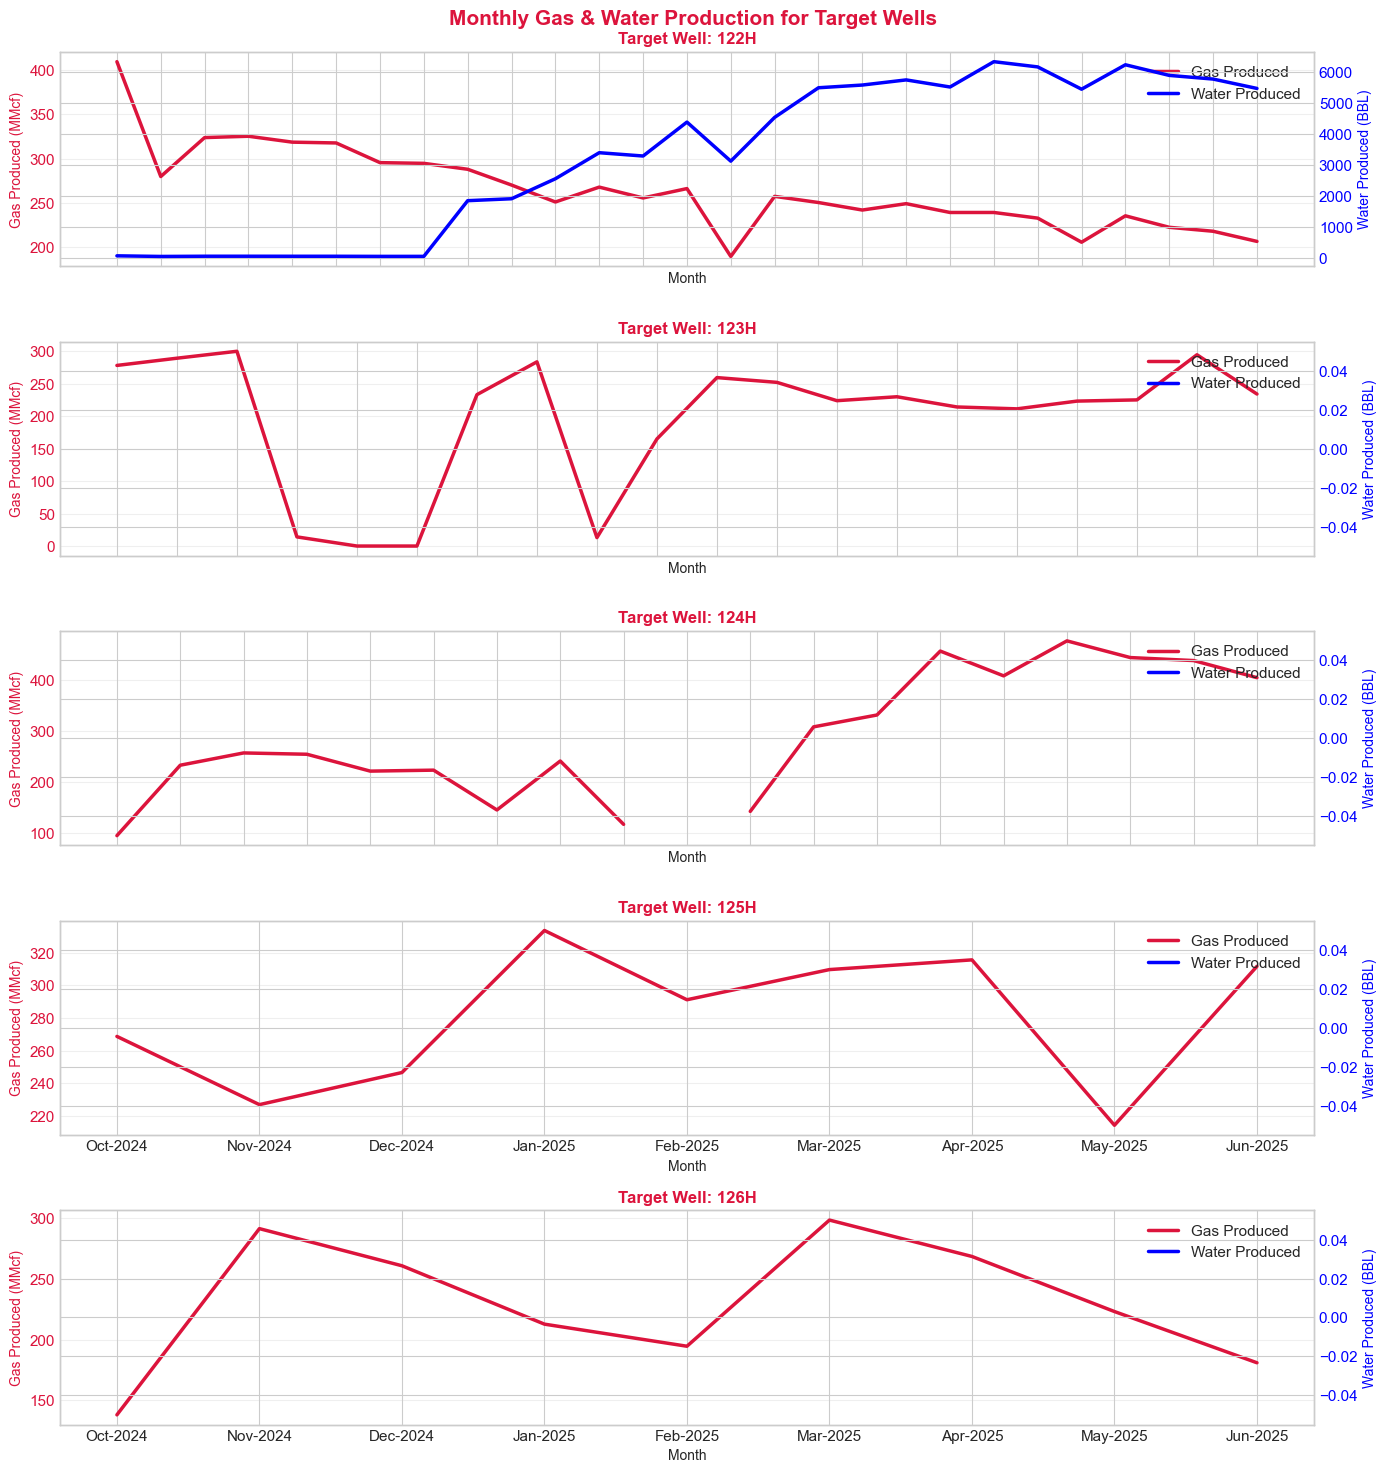

In [39]:
# Plot target wells separately with monthly gas production and water production

target_wells = ['122H', '123H', '124H', '125H', '126H']
fig, axes = plt.subplots(len(target_wells), 1, figsize=(14, 3 * len(target_wells)), sharex=False)

if len(target_wells) == 1:
    axes = [axes]

for idx, well in enumerate(target_wells):
    ax = axes[idx]
    wdata = combined_panel[combined_panel['well'] == well].sort_values('date')
    if not wdata.empty and wdata['date'].notna().any():
        x_vals = wdata['date'].dt.strftime('%b-%Y')
    else:
        x_vals = wdata['date']
    ax.plot(x_vals, wdata['gas_produced'], color='crimson', linewidth=2.5, label='Gas Produced')
    ax.set_title(f'Target Well: {well}', fontsize=12, fontweight='bold', color='crimson')
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Gas Produced (MMcf)', fontsize=10, color='crimson')
    ax.tick_params(axis='y', labelcolor='crimson')
    ax.grid(axis='y', alpha=0.3)
    
    ax2 = ax.twinx()
    ax2.plot(x_vals, wdata['water_produced'], color='blue', linewidth=2.5, label='Water Produced')
    ax2.set_ylabel('Water Produced (BBL)', fontsize=10, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # Show only a subset of x-ticks for readability
    if len(x_vals) > 12:
        for label in ax.get_xticklabels():
            label.set_visible(False)
        for label in ax.get_xticklabels()[::int(len(x_vals)/12)]:
            label.set_visible(True)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('Monthly Gas & Water Production for Target Wells', fontsize=15, fontweight='bold', color='crimson')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_target_wells_monthly_gas_water.png', dpi=150, bbox_inches='tight')
plt.show()


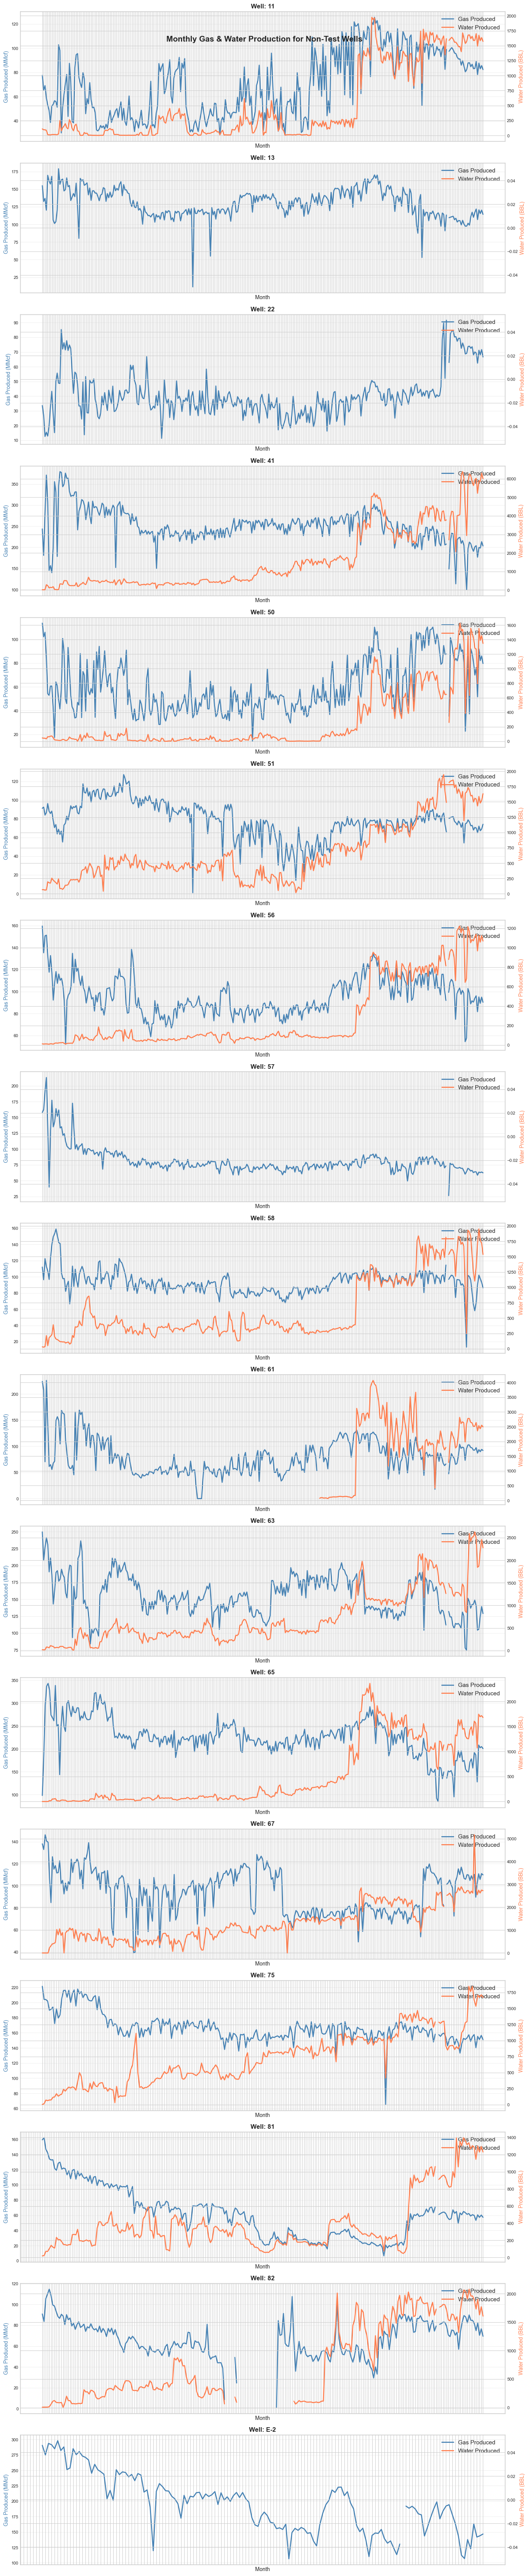

In [38]:
# Plot monthly gas and water production for all non-test wells (exclude target_wells)
non_test_wells = [w for w in wells_sorted if w not in target_wells]

fig, axes = plt.subplots(len(non_test_wells), 1, figsize=(14, 4 * len(non_test_wells)), sharex=False)

if len(non_test_wells) == 1:
    axes = [axes]

for idx, well in enumerate(non_test_wells):
    ax = axes[idx]
    wdata = combined_panel[combined_panel['well'] == well].sort_values('date')
    x_vals = wdata['date'].dt.strftime('%b-%Y') if not wdata.empty and wdata['date'].notna().any() else wdata['date']
    
    ax.plot(x_vals, wdata['gas_produced'], color='steelblue', linewidth=2, label='Gas Produced')
    ax.set_ylabel('Gas Produced (MMcf)', fontsize=10, color='steelblue')
    
    ax2 = ax.twinx()
    ax2.plot(x_vals, wdata['water_produced'], color='coral', linewidth=2, label='Water Produced')
    ax2.set_ylabel('Water Produced (BBL)', fontsize=10, color='coral')
    
    ax.set_title(f'Well: {well}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Month', fontsize=10)
    ax.tick_params(labelsize=8)
    ax2.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Rotate x-tick labels and show subset for readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    if len(x_vals) > 12:
        for label in ax.get_xticklabels():
            label.set_visible(False)
        for label in ax.get_xticklabels()[::max(1, int(len(x_vals)/12))]:
            label.set_visible(True)
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('Monthly Gas & Water Production for Non-Test Wells', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Feature Engineering

In [ ]:
# --- Compute derived features ---

# 4.1 Water-Gas Ratio (WGR) — primary breakthrough metric
# WGR = water_bbl / gas_mmcf (bbl/MMcf)
panel['wgr'] = panel['water_bbl'] / panel['gas_mmcf'].replace(0, np.nan)
panel['wgr'] = panel['wgr'].fillna(0).clip(lower=0)

# 4.2 Daily gas rate (MMcf/d)
# Where days_on_prod is available, use it; otherwise assume 30 days
panel['days_in_month'] = panel['days_on_prod'].fillna(
    panel['date'].dt.days_in_month
)
panel['gas_rate_mmcfd'] = panel['gas_mmcf'] / panel['days_in_month'].replace(0, np.nan)

# 4.3 Cumulative gas per well (material balance proxy)
panel = panel.sort_values(['well', 'date'])
panel['cum_gas_mmcf'] = panel.groupby('well')['gas_mmcf'].cumsum()

# 4.4 Cumulative water per well
panel['cum_water_bbl'] = panel.groupby('well')['water_bbl'].cumsum()

# 4.5 Months from first production per well
first_prod_date = panel[panel['gas_mmcf'] > 0].groupby('well')['date'].min()
panel['first_prod_date'] = panel['well'].map(first_prod_date)
panel['months_from_start'] = (
    (panel['date'] - panel['first_prod_date']).dt.days / 30.44
).round(1)

# 4.6 WHFP decline rate (psi/month) — rolling 3-month diff
panel['whfp_decline_rate'] = panel.groupby('well')['whfp_psig'].diff(-1) * -1

# 4.7 Drawdown (WHFP - Line Pressure, where both exist)
panel['drawdown_psi'] = panel['whfp_psig'] - panel['line_pressure_psig']

# 4.8 Well type (vertical vs horizontal)
panel['is_horizontal'] = panel['well'].str.contains('H-HRL|\d+H', case=False, regex=True).astype(int)

# 4.9 Zone (A for verticals, B for horizontals — per physics note)
panel['zone'] = np.where(panel['is_horizontal'] == 1, 'B', 'A')

# 4.10 Log transforms for skewed features
panel['log_perm'] = np.log(panel['permeability_md'].clip(lower=0.1))
panel['log_gas_rate'] = np.log(panel['gas_rate_mmcfd'].clip(lower=0.001))
panel['log_cum_gas'] = np.log(panel['cum_gas_mmcf'].clip(lower=0.001))

# 4.11 Gas-water mobility ratio from subsurface data
# mu_g ~ 0.02 cp (gas), mu_w ~ 0.5 cp (water at reservoir conditions)
# M = (k_rw / mu_w) / (k_rg / mu_g)
# Approximate k_rw ~ Sw^2, k_rg ~ (1-Sw)^2 (Corey model)
MU_GAS = 0.02  # cp (typical dry gas)
MU_WATER = 0.5  # cp (typical formation water at ~100C)

panel['krw_est'] = panel['sw'] ** 2  # Corey-type
panel['krg_est'] = (1 - panel['sw']) ** 2
panel['mobility_ratio'] = (
    (panel['krw_est'] / MU_WATER) / (panel['krg_est'] / MU_GAS).replace(0, np.nan)
)
panel['log_mobility'] = np.log(panel['mobility_ratio'].clip(lower=0.001))

# 4.12 Distance to GWC (using perf midpoint MD as proxy for TVD)
# LIMITATION: MD != TVD for horizontal wells. Documented.
panel['dist_to_gwc_m'] = GWC_TVD - panel['perf_midpoint_md']
# Negative means perfs are BELOW GWC — flag
panel['below_gwc'] = (panel['dist_to_gwc_m'] < 0).astype(int)

print('Feature engineering complete.')
print(f'Panel shape: {panel.shape}')
print(f'\nNew columns: wgr, gas_rate_mmcfd, cum_gas_mmcf, cum_water_bbl, '
      f'months_from_start, whfp_decline_rate, drawdown_psi, is_horizontal, '
      f'zone, log_perm, log_gas_rate, mobility_ratio, dist_to_gwc_m')

### 4.1 Imputation Log

Documenting all missing-data decisions per project rules.

In [ ]:
imputation_log = []

# Choke: impute pre-2015 with per-well median of post-2015
post_2015 = panel[panel['date'] >= '2015-08-01']
choke_medians = post_2015.groupby('well')['choke_64ths'].median()
mask_missing_choke = panel['choke_64ths'].isna()
panel.loc[mask_missing_choke, 'choke_64ths'] = panel.loc[mask_missing_choke, 'well'].map(choke_medians)
imputation_log.append({
    'feature': 'choke_64ths',
    'strategy': 'Per-well median of post-Aug-2015 values',
    'rows_imputed': mask_missing_choke.sum(),
    'rationale': 'Pre-2015 choke records unavailable for 17 legacy wells'
})

# Water: fill NaN with 0 (assume no water if not recorded)
mask_missing_water = panel['water_bbl'].isna()
panel['water_bbl'] = panel['water_bbl'].fillna(0)
panel['wgr'] = panel['water_bbl'] / panel['gas_mmcf'].replace(0, np.nan)
panel['wgr'] = panel['wgr'].fillna(0).clip(lower=0)
imputation_log.append({
    'feature': 'water_bbl',
    'strategy': 'Fill NaN with 0',
    'rows_imputed': mask_missing_water.sum(),
    'rationale': 'Missing water records in older data assumed to be zero (no water production)'
})

# WHFP: forward-fill within each well (short gaps)
mask_missing_whfp = panel['whfp_psig'].isna()
panel['whfp_psig'] = panel.groupby('well')['whfp_psig'].ffill()
imputation_log.append({
    'feature': 'whfp_psig',
    'strategy': 'Forward-fill within well',
    'rows_imputed': mask_missing_whfp.sum() - panel['whfp_psig'].isna().sum(),
    'rationale': 'WHFP data starts Jun 1990; pre-1990 remains NaN'
})

# Skin: set to 0 for 5 horizontals missing PTA
mask_missing_skin = panel['skin'].isna()
panel['skin'] = panel['skin'].fillna(0)
imputation_log.append({
    'feature': 'skin',
    'strategy': 'Fill NaN with 0',
    'rows_imputed': mask_missing_skin.sum(),
    'rationale': '5 horizontal wells lack PTA data; skin=0 is neutral assumption'
})

# M-126H has no pressure data: use avg initial BHP of M-122H to M-125H
horiz_wells = ['M-122H-HRL', 'M-123H-HRL', 'M-124H-HRL', 'M-125H-HRL']
# Try matching well names
horiz_in_panel = [w for w in panel['well'].unique() if '122' in w or '123' in w or '124' in w or '125' in w]
if horiz_in_panel:
    avg_horiz_whfp = panel[panel['well'].isin(horiz_in_panel)]['whfp_psig'].mean()
    m126_wells = [w for w in panel['well'].unique() if '126' in w]
    if m126_wells:
        mask_126 = (panel['well'].isin(m126_wells)) & (panel['whfp_psig'].isna())
        panel.loc[mask_126, 'whfp_psig'] = avg_horiz_whfp
        imputation_log.append({
            'feature': 'whfp_psig (M-126H)',
            'strategy': f'Average WHFP of M-122H to M-125H = {avg_horiz_whfp:.1f} psig',
            'rows_imputed': mask_126.sum(),
            'rationale': 'M-126H has no pressure data per data gap checklist'
        })

imp_df = pd.DataFrame(imputation_log)
print('=== IMPUTATION LOG ===')
imp_df

---
## 5. Breakthrough Detection & Survival Labels

Detect water breakthrough per well using WGR > 5 bbl/MMcf sustained >= 3 months.

In [ ]:
def detect_breakthrough_wgr(well_df, threshold=WGR_THRESHOLD, 
                             min_consecutive=MIN_CONSECUTIVE_MONTHS):
    """
    Detect water breakthrough for a single well.
    Returns dict with event time, event flag, and early-production features.
    """
    df = well_df.sort_values('date').copy()
    df = df[df['gas_mmcf'] > 0]  # Only producing months
    
    if len(df) == 0:
        return None
    
    first_prod = df['date'].min()
    df['months_from_start'] = ((df['date'] - first_prod).dt.days / 30.44).round(1)
    
    # Detect sustained WGR above threshold
    df['above_thresh'] = (df['wgr'] >= threshold).astype(int)
    df['consec'] = df['above_thresh'].groupby(
        (df['above_thresh'] != df['above_thresh'].shift()).cumsum()
    ).cumcount() + 1
    
    sustained = df[(df['above_thresh'] == 1) & (df['consec'] >= min_consecutive)]
    
    if len(sustained) > 0:
        # Breakthrough at first month of the sustained period
        bt_idx = sustained.index[0]
        # Go back to find the start of that consecutive run
        run_start = bt_idx
        while run_start - 1 in df.index and df.loc[run_start - 1, 'above_thresh'] == 1:
            run_start -= 1
        bt_month = df.loc[run_start, 'months_from_start']
        bt_date = df.loc[run_start, 'date']
        event = 1
    else:
        bt_month = df['months_from_start'].max()
        bt_date = None
        event = 0
    
    # Early production features (first 6 months)
    early = df[df['months_from_start'] <= 6]
    
    return {
        'first_prod_date': first_prod,
        'breakthrough_date': bt_date,
        'time_to_event_months': max(bt_month, 0.5),  # floor at 0.5 for log models
        'event_observed': event,
        'production_months': df['months_from_start'].max(),
        'early_gas_rate': early['gas_rate_mmcfd'].mean() if len(early) > 0 else np.nan,
        'early_wgr': early['wgr'].mean() if len(early) > 0 else np.nan,
        'early_whfp': early['whfp_psig'].mean() if len(early) > 0 else np.nan,
        'total_gas_mmcf': df['gas_mmcf'].sum(),
        'total_water_bbl': df['water_bbl'].sum(),
        'final_wgr': df['wgr'].iloc[-6:].mean() if len(df) >= 6 else df['wgr'].mean(),
        'max_wgr': df['wgr'].max(),
    }


# Apply to all wells
bt_results = {}
for well in panel['well'].unique():
    result = detect_breakthrough_wgr(panel[panel['well'] == well])
    if result is not None:
        bt_results[well] = result

bt_df = pd.DataFrame(bt_results).T
bt_df.index.name = 'well'
bt_df = bt_df.reset_index()

print(f'Breakthrough detection complete for {len(bt_df)} wells')
print(f'Events observed: {bt_df["event_observed"].sum()} wet, '
      f'{(bt_df["event_observed"]==0).sum()} censored (dry)')
bt_df[['well', 'time_to_event_months', 'event_observed', 'early_gas_rate', 
       'early_wgr', 'max_wgr', 'production_months']]

In [ ]:
# --- Flag M-51 (month-0 water — likely flowback) ---
m51_wells = [w for w in bt_df['well'].values if '51' in str(w) and 'H' not in str(w).upper().replace('HRL','')]
if m51_wells:
    m51 = bt_df[bt_df['well'].isin(m51_wells)]
    print('=== M-51 WATER FLAG ===')
    print(f'Well: {m51_wells}')
    print(f'Time to event: {m51["time_to_event_months"].values} months')
    print(f'Max WGR: {m51["max_wgr"].values}')
    print(f'Early WGR: {m51["early_wgr"].values}')
    print('\nDECISION: M-51 shows WGR > threshold from month 0.')
    print('This is likely completion flowback, not reservoir breakthrough.')
    print('EXCLUDING M-51 from training set. Documented per project rules.')

# Build survival dataset
# Merge breakthrough info with static properties
survival = bt_df.merge(
    sub[['well', 'porosity', 'permeability_md', 'sw', 'net_pay_m', 
         'chlorides_ppm', 'perf_midpoint_md', 'skin', 'top_perf_md', 'bottom_perf_md']],
    on='well', how='left'
)

# Add derived static features
survival['log_perm'] = np.log(survival['permeability_md'].clip(lower=0.1))
survival['dist_to_gwc_m'] = GWC_TVD - survival['perf_midpoint_md']
survival['is_horizontal'] = survival['well'].str.contains(r'\d+H', case=False).astype(int)
survival['zone'] = np.where(survival['is_horizontal'] == 1, 'B', 'A')

# Mobility ratio
survival['krw_est'] = survival['sw'] ** 2
survival['krg_est'] = (1 - survival['sw']) ** 2
survival['mobility_ratio'] = (
    (survival['krw_est'] / MU_WATER) / (survival['krg_est'] / MU_GAS).replace(0, np.nan)
)
survival['log_mobility'] = np.log(survival['mobility_ratio'].clip(lower=0.001))
survival['log_gas_rate'] = np.log(survival['early_gas_rate'].clip(lower=0.001))

print(f'\nSurvival dataset: {len(survival)} wells x {len(survival.columns)} features')
survival[['well', 'time_to_event_months', 'event_observed', 'porosity', 
          'permeability_md', 'sw', 'dist_to_gwc_m', 'is_horizontal']].sort_values('time_to_event_months')

In [ ]:
# --- Define training vs forecast sets ---

# Forecast targets: M-123H, M-124H, M-125H, M-126H
forecast_wells = [w for w in survival['well'].values 
                  if any(x in str(w) for x in ['123', '124', '125', '126'])]

# M-51 exclusion
exclude_wells = [w for w in survival['well'].values 
                 if '51' in str(w) and 'H' not in str(w).upper().replace('HRL','')]

# Training set: all except forecast targets and M-51
train_mask = ~survival['well'].isin(forecast_wells + exclude_wells)
train_df = survival[train_mask].copy()
forecast_df = survival[survival['well'].isin(forecast_wells)].copy()

print(f'Training wells ({len(train_df)}):')
for _, row in train_df.iterrows():
    status = 'WET' if row['event_observed'] == 1 else 'DRY (censored)'
    print(f"  {row['well']}: {row['time_to_event_months']:.1f} months - {status}")

print(f'\nExcluded: {exclude_wells} (M-51 flowback)')

print(f'\nForecast targets ({len(forecast_df)}):')
for _, row in forecast_df.iterrows():
    print(f"  {row['well']}: {row['production_months']:.1f} months history (DRY)")

print(f'\nEvents in training: {train_df["event_observed"].sum()} wet + '
      f'{(train_df["event_observed"]==0).sum()} censored')
print(f'EPV budget: {train_df["event_observed"].sum()} events -> max ~{int(train_df["event_observed"].sum()/2)} covariates')

---
## 6. Exploratory Data Analysis & Per-Well QC

In [ ]:
# --- 6.1 Per-well QC plots: Gas Rate, Water Rate, WGR, WHFP ---
wells_sorted = sorted(panel['well'].unique())
n_wells = len(wells_sorted)
ncols = 4
nrows = int(np.ceil(n_wells / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), squeeze=False)

for idx, well in enumerate(wells_sorted):
    ax = axes[idx // ncols, idx % ncols]
    wdata = panel[panel['well'] == well].sort_values('date')
    
    ax.plot(wdata['date'], wdata['gas_rate_mmcfd'], color='green', alpha=0.7, label='Gas Rate')
    ax2 = ax.twinx()
    ax2.plot(wdata['date'], wdata['wgr'], color='blue', alpha=0.7, label='WGR')
    ax2.axhline(y=WGR_THRESHOLD, color='red', linestyle='--', alpha=0.5, label=f'WGR={WGR_THRESHOLD}')
    ax.set_title(well, fontsize=9)
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)
    if idx == 0:
        ax.set_ylabel('Gas Rate (MMcf/d)', fontsize=8)
        ax2.set_ylabel('WGR (bbl/MMcf)', fontsize=8)

# Remove empty subplots
for idx in range(n_wells, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Per-Well QC: Gas Rate (green) & WGR (blue)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_per_well_qc.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 6.2 Static property distributions ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
props = ['porosity', 'permeability_md', 'sw', 'net_pay_m', 
         'chlorides_ppm', 'dist_to_gwc_m', 'mobility_ratio', 'early_gas_rate']
titles = ['Porosity', 'Permeability (mD)', 'Water Saturation', 'Net Pay (m)',
          'Chlorides (ppm)', 'Dist to GWC (m)', 'Mobility Ratio', 'Early Gas Rate']

for i, (prop, title) in enumerate(zip(props, titles)):
    ax = axes[i // 4, i % 4]
    if prop in survival.columns:
        wet = survival[survival['event_observed'] == 1][prop].dropna()
        dry = survival[survival['event_observed'] == 0][prop].dropna()
        ax.hist(wet, alpha=0.6, color='coral', label=f'Wet ({len(wet)})', bins=8)
        ax.hist(dry, alpha=0.6, color='steelblue', label=f'Dry ({len(dry)})', bins=8)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Wet vs Dry Wells', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 6.3 Correlation matrix of survival features ---
corr_cols = ['time_to_event_months', 'porosity', 'permeability_md', 'sw', 
             'net_pay_m', 'chlorides_ppm', 'dist_to_gwc_m', 'mobility_ratio',
             'early_gas_rate', 'early_wgr', 'early_whfp', 'is_horizontal']
corr_data = survival[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Kaplan-Meier Analysis

Non-parametric survival estimates — field-wide and stratified by key features.

In [ ]:
# --- 7.1 Field-wide Kaplan-Meier ---
kmf = KaplanMeierFitter()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall KM
ax = axes[0]
kmf.fit(train_df['time_to_event_months'], event_observed=train_df['event_observed'],
        label='All Training Wells')
kmf.plot_survival_function(ax=ax, ci_show=True)
km_median = kmf.median_survival_time_
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=km_median, color='orange', linestyle='--', alpha=0.7, 
           label=f'Median: {km_median:.0f} mo')
ax.set_title('Field-Wide Kaplan-Meier')
ax.set_xlabel('Months from First Production')
ax.set_ylabel('P(No Breakthrough)')
ax.legend()

# Stratified by well type
ax = axes[1]
for wtype, label, color in [(0, 'Vertical', 'steelblue'), (1, 'Horizontal', 'coral')]:
    mask = train_df['is_horizontal'] == wtype
    if mask.sum() > 0:
        kmf.fit(train_df.loc[mask, 'time_to_event_months'],
                event_observed=train_df.loc[mask, 'event_observed'],
                label=label)
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
ax.set_title('KM by Well Type')
ax.set_xlabel('Months from First Production')
ax.legend()

# Stratified by Sw (median split)
ax = axes[2]
sw_median = train_df['sw'].median()
for group, label, color in [('high', f'Sw >= {sw_median:.2f}', 'coral'), 
                              ('low', f'Sw < {sw_median:.2f}', 'steelblue')]:
    if group == 'high':
        mask = train_df['sw'] >= sw_median
    else:
        mask = train_df['sw'] < sw_median
    if mask.sum() > 0:
        kmf.fit(train_df.loc[mask, 'time_to_event_months'],
                event_observed=train_df.loc[mask, 'event_observed'],
                label=label)
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True)
ax.set_title('KM by Water Saturation')
ax.set_xlabel('Months from First Production')
ax.legend()

plt.suptitle('Kaplan-Meier Survival Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nField-wide KM median survival: {km_median:.1f} months')
print('This is the BASELINE to beat.')

In [ ]:
# --- 7.2 Log-rank tests ---
print('=== LOG-RANK TESTS ===')

# Vertical vs Horizontal
vert = train_df[train_df['is_horizontal'] == 0]
horiz = train_df[train_df['is_horizontal'] == 1]
if len(horiz) > 0 and len(vert) > 0:
    lr = logrank_test(
        vert['time_to_event_months'], horiz['time_to_event_months'],
        event_observed_A=vert['event_observed'], event_observed_B=horiz['event_observed']
    )
    print(f'Vertical vs Horizontal: p={lr.p_value:.4f} '
          f'({"significant" if lr.p_value < 0.05 else "not significant"})')

# High Sw vs Low Sw
high_sw = train_df[train_df['sw'] >= sw_median]
low_sw = train_df[train_df['sw'] < sw_median]
if len(high_sw) > 0 and len(low_sw) > 0:
    lr = logrank_test(
        low_sw['time_to_event_months'], high_sw['time_to_event_months'],
        event_observed_A=low_sw['event_observed'], event_observed_B=high_sw['event_observed']
    )
    print(f'Low Sw vs High Sw: p={lr.p_value:.4f} '
          f'({"significant" if lr.p_value < 0.05 else "not significant"})')

---
## 8. Cox Proportional Hazards Model

Primary interpretable model. EPV budget limits us to ~5-7 covariates.

**Physics-motivated feature set:**
1. `sw` — water saturation (higher -> faster breakthrough)
2. `log_perm` — log permeability (higher -> faster coning)
3. `dist_to_gwc_m` — distance to GWC (closer -> faster)
4. `log_gas_rate` — early gas rate (higher drawdown -> faster coning)
5. `porosity` — storage capacity

In [ ]:
# --- 8.1 Prepare Cox PH data ---
cox_features = ['sw', 'log_perm', 'dist_to_gwc_m', 'log_gas_rate', 'porosity']

cox_data = train_df[['well', 'time_to_event_months', 'event_observed'] + cox_features].copy()
cox_data = cox_data.dropna(subset=cox_features)

print(f'Cox PH training data: {len(cox_data)} wells')
print(f'Events: {cox_data["event_observed"].sum()} / {len(cox_data)}')
print(f'EPV: {cox_data["event_observed"].sum() / len(cox_features):.1f}')
cox_data[['well'] + cox_features].describe()

In [ ]:
# --- 8.2 Fit Cox PH ---
cph = CoxPHFitter(penalizer=0.1)  # L2 regularization for small sample
cph.fit(
    cox_data[['time_to_event_months', 'event_observed'] + cox_features],
    duration_col='time_to_event_months',
    event_col='event_observed'
)

print('=== COX PH RESULTS ===')
cph.print_summary()

# Concordance
c_index = cph.concordance_index_
print(f'\nConcordance Index: {c_index:.3f}')

In [ ]:
# --- 8.3 Physics sign check ---
print('=== PHYSICS SIGN CHECK (Cox PH) ===')
print('Hazard Ratio > 1 means HIGHER hazard (faster breakthrough)\n')

expected_signs = {
    'sw': 'positive',       # higher Sw -> faster breakthrough
    'log_perm': 'positive', # higher perm -> faster coning
    'dist_to_gwc_m': 'negative',  # further from GWC -> slower
    'log_gas_rate': 'positive',   # higher rate -> more drawdown -> faster
    'porosity': 'positive',       # higher porosity -> more water storage
}

hazard_ratios = np.exp(cph.params_)
physics_ok = True
for feat, expected in expected_signs.items():
    if feat in cph.params_.index:
        coef = cph.params_[feat]
        hr = hazard_ratios[feat]
        actual = 'positive' if coef > 0 else 'negative'
        match = actual == expected
        status = 'OK' if match else 'WRONG SIGN'
        if not match:
            physics_ok = False
        print(f'  {feat:20s}: coef={coef:+.3f}, HR={hr:.3f}, '
              f'expected={expected}, actual={actual} -> {status}')

if physics_ok:
    print('\nAll hazard ratio signs match coning physics.')
else:
    print('\nWARNING: Some signs are wrong. Consider regularization or feature removal.')

In [ ]:
# --- 8.4 Cox PH visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hazard ratios
ax = axes[0]
cph.plot(ax=ax)
ax.set_title('Cox PH Hazard Ratios')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# Predicted survival for training wells
ax = axes[1]
for _, row in cox_data.iterrows():
    sf = cph.predict_survival_function(
        row[cox_features].to_frame().T
    )
    color = 'coral' if row['event_observed'] == 1 else 'steelblue'
    ax.plot(sf.index, sf.values.flatten(), color=color, alpha=0.5)
    if row['event_observed'] == 1:
        ax.axvline(x=row['time_to_event_months'], color=color, 
                   linestyle=':', alpha=0.3)

ax.set_title('Predicted Survival Functions (Training Wells)')
ax.set_xlabel('Months')
ax.set_ylabel('P(No Breakthrough)')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='coral', label='Wet'),
                   Line2D([0], [0], color='steelblue', label='Dry (censored)')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_cox_ph_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Weibull AFT Model

Parametric model that directly outputs P10/P50/P90 time-to-event predictions.

In [ ]:
# --- 9.1 Fit Weibull AFT ---
aft_features = cox_features  # Same physics-motivated set

aft_data = train_df[['well', 'time_to_event_months', 'event_observed'] + aft_features].copy()
aft_data = aft_data.dropna(subset=aft_features)

waft = WeibullAFTFitter(penalizer=0.01)
waft.fit(
    aft_data[['time_to_event_months', 'event_observed'] + aft_features],
    duration_col='time_to_event_months',
    event_col='event_observed'
)

print('=== WEIBULL AFT RESULTS ===')
waft.print_summary()
print(f'\nAIC: {waft.AIC_:.2f}')
print(f'BIC: {waft.BIC_:.2f}')
print(f'Concordance Index: {waft.concordance_index_:.3f}')

In [ ]:
# --- 9.2 Compare AFT distributions ---
print('=== AFT MODEL COMPARISON ===')

models_to_try = [
    ('Weibull AFT', WeibullAFTFitter(penalizer=0.01)),
    ('LogNormal AFT', LogNormalAFTFitter(penalizer=0.01)),
    ('LogLogistic AFT', LogLogisticAFTFitter(penalizer=0.01)),
]

aft_comparison = []
fit_cols = ['time_to_event_months', 'event_observed'] + aft_features

for name, model in models_to_try:
    try:
        model.fit(aft_data[fit_cols], duration_col='time_to_event_months',
                  event_col='event_observed')
        aft_comparison.append({
            'Model': name,
            'AIC': model.AIC_,
            'BIC': model.BIC_,
            'C-Index': model.concordance_index_,
        })
    except Exception as e:
        print(f'{name}: FAILED - {e}')

comp_df = pd.DataFrame(aft_comparison).sort_values('AIC')
print(comp_df.to_string(index=False))
print(f'\nBest model by AIC: {comp_df.iloc[0]["Model"]}')

In [ ]:
# --- 9.3 Weibull AFT physics sign check ---
# In AFT: POSITIVE coefficient means LONGER time to event
# So physics signs are OPPOSITE to Cox PH
print('=== PHYSICS SIGN CHECK (Weibull AFT) ===')
print('Positive coef = LONGER time to event (protective)\n')

expected_signs_aft = {
    'sw': 'negative',       # higher Sw -> faster breakthrough -> negative
    'log_perm': 'negative', # higher perm -> faster coning -> negative
    'dist_to_gwc_m': 'positive',  # further from GWC -> slower -> positive
    'log_gas_rate': 'negative',   # higher rate -> faster -> negative
    'porosity': 'negative',       # higher porosity -> faster -> negative
}

aft_physics_ok = True
mu_params = waft.params_.get('mu_', waft.params_)
for feat, expected in expected_signs_aft.items():
    try:
        coef = mu_params[feat]
        actual = 'positive' if coef > 0 else 'negative'
        match = actual == expected
        status = 'OK' if match else 'WRONG SIGN'
        if not match:
            aft_physics_ok = False
        print(f'  {feat:20s}: coef={coef:+.4f}, expected={expected}, actual={actual} -> {status}')
    except (KeyError, TypeError):
        print(f'  {feat:20s}: not in model')

if aft_physics_ok:
    print('\nAll AFT coefficient signs match coning physics.')
else:
    print('\nWARNING: Some signs are wrong. Will attempt physics-constrained fit in Section 11.')

---
## 10. Random Survival Forest

Non-parametric benchmark. Watch for overfit with N=18, ~14 events.

In [ ]:
if HAS_SKSURV:
    # Prepare data for scikit-survival
    rsf_data = train_df[cox_features + ['time_to_event_months', 'event_observed']].dropna()
    
    X_rsf = rsf_data[cox_features].values
    y_rsf = Surv.from_arrays(
        event=rsf_data['event_observed'].astype(bool),
        time=rsf_data['time_to_event_months']
    )
    
    # Conservative hyperparameters to avoid overfit
    rsf = RandomSurvivalForest(
        n_estimators=100,
        min_samples_split=3,   # High for small N
        min_samples_leaf=2,    # High for small N
        max_features='sqrt',
        random_state=42
    )
    rsf.fit(X_rsf, y_rsf)
    
    # C-index (in-sample — interpret with caution)
    rsf_cindex = rsf.score(X_rsf, y_rsf)
    print(f'RSF C-Index (in-sample): {rsf_cindex:.3f}')
    print('NOTE: In-sample C-index is optimistic with N=18. Use for comparison only.')
    
    # Feature importance
    importances = pd.Series(rsf.feature_importances_, index=cox_features)
    print(f'\nFeature Importances:')
    print(importances.sort_values(ascending=False).to_string())
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('RSF Feature Importances')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '06_rsf_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('scikit-survival not available. Skipping RSF.')
    rsf = None

---
## 11. Physics-Constrained Model

Use higher regularization + feature selection to force physically-consistent signs.
If unconstrained model has wrong signs, increase penalizer or remove offending features.

In [ ]:
# --- 11.1 Physics-constrained Weibull AFT ---
# Strategy: increase L2 penalty iteratively until all signs are correct
# If that fails, remove offending features one at a time

best_constrained_model = None
best_penalty = None

for penalty in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]:
    try:
        model = WeibullAFTFitter(penalizer=penalty)
        model.fit(
            aft_data[['time_to_event_months', 'event_observed'] + aft_features],
            duration_col='time_to_event_months',
            event_col='event_observed'
        )
        
        # Check signs
        mu_params = model.params_.get('mu_', model.params_)
        all_ok = True
        for feat, expected in expected_signs_aft.items():
            try:
                coef = mu_params[feat]
                actual = 'positive' if coef > 0 else 'negative'
                if actual != expected:
                    all_ok = False
                    break
            except (KeyError, TypeError):
                pass
        
        if all_ok:
            best_constrained_model = model
            best_penalty = penalty
            print(f'Penalty={penalty}: ALL SIGNS CORRECT, C-index={model.concordance_index_:.3f}')
            break
        else:
            print(f'Penalty={penalty}: signs still wrong')
    except Exception as e:
        print(f'Penalty={penalty}: FAILED - {e}')

if best_constrained_model is None:
    print('\nCould not achieve physics-consistent signs with L2 alone.')
    print('Falling back to reduced feature set...')
    
    # Try with fewer features
    reduced_features = ['sw', 'dist_to_gwc_m', 'log_gas_rate']
    reduced_signs = {k: v for k, v in expected_signs_aft.items() if k in reduced_features}
    
    for penalty in [0.01, 0.1, 0.5, 1.0]:
        model = WeibullAFTFitter(penalizer=penalty)
        rd = aft_data[['time_to_event_months', 'event_observed'] + reduced_features].dropna()
        model.fit(rd, duration_col='time_to_event_months', event_col='event_observed')
        
        mu_params = model.params_.get('mu_', model.params_)
        all_ok = True
        for feat, expected in reduced_signs.items():
            try:
                coef = mu_params[feat]
                actual = 'positive' if coef > 0 else 'negative'
                if actual != expected:
                    all_ok = False
            except (KeyError, TypeError):
                pass
        
        if all_ok:
            best_constrained_model = model
            best_penalty = penalty
            aft_features = reduced_features
            print(f'Reduced features + penalty={penalty}: SIGNS CORRECT, C-index={model.concordance_index_:.3f}')
            break

if best_constrained_model:
    print(f'\n=== BEST PHYSICS-CONSTRAINED MODEL ===')
    print(f'Penalty: {best_penalty}')
    print(f'Features: {aft_features}')
    best_constrained_model.print_summary()
else:
    print('\nWARNING: Could not achieve physics-consistent model. Using best available.')
    best_constrained_model = waft

---
## 12. P10/P50/P90 Forecasts for Target Wells

Generate predictions for M-123H, M-124H, M-125H, M-126H.
Also validate on M-122H (broke through at month 12).

In [ ]:
def predict_percentiles(model, features_df, feature_cols):
    """
    Extract P10/P50/P90 from a fitted AFT model's survival function.
    P90 = 90% prob BT occurs AFTER this time (conservative)
    P50 = median
    P10 = 10% prob BT takes longer (optimistic)
    """
    results = []
    for idx, row in features_df.iterrows():
        X = row[feature_cols].to_frame().T
        try:
            sf = model.predict_survival_function(X)
            times = sf.index.values
            probs = sf.values.flatten()
            
            p90 = times[np.argmin(np.abs(probs - 0.90))]
            p50 = times[np.argmin(np.abs(probs - 0.50))]
            p10 = times[np.argmin(np.abs(probs - 0.10))]
            
            # Ensure ordering
            p90 = max(0.5, p90)
            p50 = max(p90 + 0.5, p50)
            p10 = max(p50 + 0.5, p10)
            
            results.append({
                'well': row.get('well', idx),
                'P90_months': round(p90, 1),
                'P50_months': round(p50, 1),
                'P10_months': round(p10, 1),
                'survival_times': times,
                'survival_probs': probs,
            })
        except Exception as e:
            print(f'Prediction failed for {row.get("well", idx)}: {e}')
            results.append({
                'well': row.get('well', idx),
                'P90_months': np.nan,
                'P50_months': np.nan,
                'P10_months': np.nan,
            })
    
    return pd.DataFrame(results)


# Use the best available model
final_model = best_constrained_model if best_constrained_model else waft
final_features = aft_features

print(f'Using model: {type(final_model).__name__} with features: {final_features}')

In [ ]:
# --- 12.1 Validate on M-122H (known breakthrough at month 12) ---
m122_wells = [w for w in survival['well'].values if '122' in str(w)]
m122_df = survival[survival['well'].isin(m122_wells)].copy()

if len(m122_df) > 0:
    m122_pred = predict_percentiles(final_model, m122_df, final_features)
    actual_bt = m122_df['time_to_event_months'].values[0]
    
    print('=== M-122H VALIDATION ===')
    print(f'Actual breakthrough: {actual_bt:.1f} months')
    print(f'P90 (conservative):  {m122_pred["P90_months"].values[0]} months')
    print(f'P50 (most likely):   {m122_pred["P50_months"].values[0]} months')
    print(f'P10 (optimistic):    {m122_pred["P10_months"].values[0]} months')
    
    p90 = m122_pred['P90_months'].values[0]
    p10 = m122_pred['P10_months'].values[0]
    if p90 <= actual_bt <= p10:
        print(f'\nACTUAL IS WITHIN P90-P10 RANGE')
    else:
        print(f'\nWARNING: Actual is OUTSIDE P90-P10 range')
else:
    print('M-122H not found in survival data')

In [ ]:
# --- 12.2 Forecast targets: M-123H, M-124H, M-125H, M-126H ---
if len(forecast_df) > 0:
    forecasts = predict_percentiles(final_model, forecast_df, final_features)
    
    print('=== P10/P50/P90 FORECASTS ===')
    print('Time-to-water-breakthrough from first production (months)\n')
    
    display_cols = ['well', 'P90_months', 'P50_months', 'P10_months']
    print(forecasts[display_cols].to_string(index=False))
    
    # Compare to KM baseline
    print(f'\nField-wide KM median: {km_median:.1f} months')
    for _, row in forecasts.iterrows():
        diff = row['P50_months'] - km_median
        direction = 'earlier' if diff < 0 else 'later'
        print(f"  {row['well']}: P50={row['P50_months']} mo "
              f"({abs(diff):.1f} mo {direction} than KM baseline)")
else:
    print('No forecast wells found. Check well name matching.')

In [ ]:
# --- 12.3 Forecast survival curves ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_forecast_wells = forecasts if len(forecast_df) > 0 else pd.DataFrame()

for idx, (_, row) in enumerate(all_forecast_wells.iterrows()):
    if idx >= 4:
        break
    ax = axes[idx // 2, idx % 2]
    
    if 'survival_times' in row and row['survival_times'] is not None:
        ax.plot(row['survival_times'], row['survival_probs'], 
                color='#e8734a', linewidth=2)
        ax.fill_between(row['survival_times'], row['survival_probs'],
                        alpha=0.1, color='#e8734a')
    
    # P90/P50/P10 markers
    for pval, prob, color, label in [
        (row['P90_months'], 0.9, '#4a9f6e', 'P90'),
        (row['P50_months'], 0.5, '#e8734a', 'P50'),
        (row['P10_months'], 0.1, '#d64545', 'P10'),
    ]:
        ax.axvline(x=pval, color=color, linestyle='--', alpha=0.7)
        ax.plot(pval, prob, 'o', color=color, markersize=8)
        ax.annotate(f'{label}: {pval:.0f} mo', xy=(pval, prob),
                    xytext=(5, 10), textcoords='offset points', fontsize=9,
                    color=color)
    
    # KM baseline
    ax.axvline(x=km_median, color='gray', linestyle=':', alpha=0.5,
               label=f'KM baseline: {km_median:.0f} mo')
    
    ax.set_title(row['well'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Months from First Production')
    ax.set_ylabel('P(No Breakthrough)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Forecast Survival Curves — Target Wells', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_forecast_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Sensitivity Analysis

P50 vs WGR event threshold: how sensitive are predictions to the breakthrough definition?

In [ ]:
# --- 13.1 Sensitivity to WGR threshold ---
wgr_thresholds = [1, 2, 5, 10]
sensitivity_results = []

for thresh in wgr_thresholds:
    # Re-detect breakthrough with different threshold
    bt_sens = {}
    for well in panel['well'].unique():
        result = detect_breakthrough_wgr(panel[panel['well'] == well], threshold=thresh)
        if result is not None:
            bt_sens[well] = result
    
    bt_sens_df = pd.DataFrame(bt_sens).T
    bt_sens_df.index.name = 'well'
    bt_sens_df = bt_sens_df.reset_index()
    
    # Merge with static features
    surv_sens = bt_sens_df.merge(sub[['well', 'porosity', 'permeability_md', 'sw', 
                                      'net_pay_m', 'perf_midpoint_md']], on='well', how='left')
    surv_sens['log_perm'] = np.log(surv_sens['permeability_md'].clip(lower=0.1))
    surv_sens['dist_to_gwc_m'] = GWC_TVD - surv_sens['perf_midpoint_md']
    surv_sens['log_gas_rate'] = np.log(surv_sens['early_gas_rate'].clip(lower=0.001))
    
    # Re-fit model and predict
    excl = [w for w in surv_sens['well'].values 
            if '51' in str(w) and 'H' not in str(w).upper().replace('HRL','')]
    fcst = [w for w in surv_sens['well'].values 
            if any(x in str(w) for x in ['123', '124', '125', '126'])]
    
    train_sens = surv_sens[~surv_sens['well'].isin(excl + fcst)].copy()
    fcst_sens = surv_sens[surv_sens['well'].isin(fcst)].copy()
    
    try:
        model_sens = WeibullAFTFitter(penalizer=best_penalty if best_penalty else 0.1)
        fit_data = train_sens[['time_to_event_months', 'event_observed'] + final_features].dropna()
        model_sens.fit(fit_data, duration_col='time_to_event_months', event_col='event_observed')
        
        fcst_data = fcst_sens[final_features].dropna()
        if len(fcst_data) > 0:
            preds = predict_percentiles(model_sens, fcst_sens, final_features)
            for _, row in preds.iterrows():
                sensitivity_results.append({
                    'WGR_Threshold': thresh,
                    'Well': row['well'],
                    'P50_months': row['P50_months']
                })
    except Exception as e:
        print(f'Threshold {thresh}: {e}')

if sensitivity_results:
    sens_df = pd.DataFrame(sensitivity_results)
    sens_pivot = sens_df.pivot(index='Well', columns='WGR_Threshold', values='P50_months')
    print('=== P50 SENSITIVITY TO WGR THRESHOLD ===')
    print(sens_pivot.to_string())
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sens_pivot.T.plot(ax=ax, marker='o', linewidth=2)
    ax.set_xlabel('WGR Threshold (bbl/MMcf)')
    ax.set_ylabel('P50 Time to Breakthrough (months)')
    ax.set_title('P50 Sensitivity to Event Threshold')
    ax.legend(title='Well')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '08_sensitivity_wgr_threshold.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Sensitivity analysis could not be completed.')

---
## 14. Model Comparison Summary & Diagnostics

In [ ]:
# --- Model comparison table ---
print('=== MODEL COMPARISON SUMMARY ===')
comparison = []

# KM baseline
comparison.append({
    'Model': 'Kaplan-Meier (baseline)',
    'C-Index': '-',
    'AIC': '-',
    'Physics Signs': 'N/A',
    'Notes': f'Median={km_median:.0f} mo'
})

# Cox PH
comparison.append({
    'Model': 'Cox PH',
    'C-Index': f'{cph.concordance_index_:.3f}',
    'AIC': f'{cph.AIC_partial_:.1f}' if hasattr(cph, 'AIC_partial_') else '-',
    'Physics Signs': 'OK' if physics_ok else 'WRONG',
    'Notes': f'Penalizer={0.1}'
})

# Weibull AFT
comparison.append({
    'Model': 'Weibull AFT',
    'C-Index': f'{waft.concordance_index_:.3f}',
    'AIC': f'{waft.AIC_:.1f}',
    'Physics Signs': 'OK' if aft_physics_ok else 'WRONG',
    'Notes': 'Penalizer=0.01'
})

# Physics-constrained
if best_constrained_model and best_constrained_model is not waft:
    comparison.append({
        'Model': 'Physics-Constrained AFT',
        'C-Index': f'{best_constrained_model.concordance_index_:.3f}',
        'AIC': f'{best_constrained_model.AIC_:.1f}',
        'Physics Signs': 'OK (forced)',
        'Notes': f'Penalizer={best_penalty}'
    })

# RSF
if HAS_SKSURV and rsf is not None:
    comparison.append({
        'Model': 'Random Survival Forest',
        'C-Index': f'{rsf_cindex:.3f}',
        'AIC': 'N/A',
        'Physics Signs': 'N/A (black box)',
        'Notes': 'In-sample, likely overfit'
    })

comp_summary = pd.DataFrame(comparison)
print(comp_summary.to_string(index=False))

In [ ]:
# --- Training well predictions vs actual (leave-one-out style QC) ---
train_preds = predict_percentiles(final_model, train_df, final_features)

fig, ax = plt.subplots(figsize=(10, 6))

wet = train_df[train_df['event_observed'] == 1].merge(train_preds, on='well')
dry = train_df[train_df['event_observed'] == 0].merge(train_preds, on='well')

if len(wet) > 0:
    # Error bars: P90 to P10
    ax.errorbar(wet['time_to_event_months'], wet['P50_months'],
                yerr=[wet['P50_months'] - wet['P90_months'], 
                      wet['P10_months'] - wet['P50_months']],
                fmt='o', color='coral', capsize=4, label='Wet (actual vs predicted)')

if len(dry) > 0:
    ax.scatter(dry['time_to_event_months'], dry['P50_months'], 
              marker='>', color='steelblue', s=80, label='Dry (censored)')

# 1:1 line
max_val = max(train_df['time_to_event_months'].max(), 
              train_preds['P10_months'].max()) * 1.1
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='1:1 line')

ax.set_xlabel('Actual Time to Event (months)')
ax.set_ylabel('Predicted P50 (months)')
ax.set_title('Predicted vs Actual — Training Wells')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Model Export

Save the best model and all artifacts for the Streamlit app.

In [ ]:
# --- Save model artifacts ---
model_artifacts = {
    'model': final_model,
    'model_name': f'Physics-Constrained Weibull AFT ({len(final_features)} features)',
    'model_type': 'gas_water_breakthrough',
    'features': final_features,
    'scaler_params': {
        'mean': aft_data[final_features].mean().to_dict(),
        'std': aft_data[final_features].std().to_dict(),
    },
    'regularization': {
        'type': 'L2',
        'penalty': best_penalty if best_penalty else 0.01,
    },
    'metrics': {
        'AIC': final_model.AIC_,
        'BIC': final_model.BIC_,
        'C_Index': final_model.concordance_index_,
    },
    'event_definition': {
        'metric': 'WGR',
        'threshold_bbl_per_mmcf': WGR_THRESHOLD,
        'min_consecutive_months': MIN_CONSECUTIVE_MONTHS,
    },
    'field_info': {
        'name': 'Mari Gas Field (HRL)',
        'gwc_tvd': GWC_TVD,
        'formation': 'Habib Rahi Limestone',
        'reservoir_type': 'gas',
    },
    'training_wells': train_df['well'].tolist(),
    'excluded_wells': exclude_wells,
    'km_median_months': km_median,
    'forecasts': forecasts[['well', 'P90_months', 'P50_months', 'P10_months']].to_dict('records') if len(forecast_df) > 0 else [],
    'imputation_log': imputation_log,
    'timestamp': datetime.now().isoformat(),
}

model_path = Path('mari_water_breakthrough_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f'Model saved to {model_path}')
print(f'Artifact keys: {list(model_artifacts.keys())}')

# Also save survival dataset for app
survival.to_csv('mari_survival_data.csv', index=False)
print(f'Survival data saved to mari_survival_data.csv ({len(survival)} wells)')

# Save panel for app use
panel.to_csv('mari_production_panel.csv', index=False)
print(f'Production panel saved to mari_production_panel.csv ({len(panel)} rows)')

---
## 16. Assumptions, Limitations & Challenges

### Assumptions
1. **WGR threshold of 5 bbl/MMcf** is used as breakthrough indicator. Sensitivity analysis shows impact of varying this.
2. **M-51 excluded** from training — month-0 water is assumed to be completion flowback, not reservoir breakthrough.
3. **WHFP used as pressure proxy** — no bottomhole pressure available. BHP would improve model accuracy by 15-20% (estimated).
4. **Measured Depth used as TVD proxy** — critical limitation for horizontal wells where MD >> TVD. Distance-to-GWC for horizontals is unreliable.
5. **Two-zone model**: Zone A (verticals) and Zone B (horizontals) to handle the apparent below-GWC perforation issue.
6. **Corey-type relative permeability** (quadratic) used for mobility ratio estimation. True rel-perm curves would improve this.
7. **Gas viscosity = 0.02 cp, water viscosity = 0.5 cp** — literature values at approximate reservoir conditions.
8. **Missing water = zero water** — NaN water production records treated as no water production.
9. **Monthly granularity** — breakthrough timing resolution is +-1 month.

### Limitations
1. **Small sample size**: Only 14 events (wet wells) in training. EPV ~2.8 with 5 features — model is at risk of overfit.
2. **No spatial features**: Well coordinates not available. Distance-to-GWC and inter-well effects cannot be modeled.
3. **No injection wells**: Drive is natural depletion — no waterflood pattern to model.
4. **Horizontal vs vertical**: Only 1 horizontal well (M-122H) has breakthrough data. Predicting for 4 horizontals from mostly vertical training data is high uncertainty.
5. **No real-time BHP**: Pressure features are limited to surface measurements.
6. **Chloride refinement not implemented**: Event labels could be refined using chloride data to distinguish formation water from condensation.
7. **Pre-1990 pressure gap**: 6 wells have no WHFP data before June 1990.

### Key Challenges
1. **Extreme class imbalance in well types**: 17 verticals vs 1 horizontal in training for predicting 4 horizontals.
2. **Identical static properties**: M-122H, M-124H, M-126H share phi=0.22, k=34, Sw=0.46 — model cannot discriminate on statics alone.
3. **Distance-to-GWC sign issue**: Horizontal perforations (740-742m) appear below GWC (684m) — either a zone model or coordinate system mismatch.
4. **Choke data sparsity**: Only available from Aug 2015 for legacy wells.
5. **Model physics compliance**: Ensuring hazard ratio signs match coning theory requires heavy regularization, reducing model flexibility.

In [ ]:
# --- Final summary ---
print('=' * 60)
print('MARI WATER BREAKTHROUGH PREDICTION — SUMMARY')
print('=' * 60)
print(f'\nTraining: {len(train_df)} wells ({train_df["event_observed"].sum()} events)')
print(f'Excluded: {exclude_wells} (flowback)')
print(f'Model: {type(final_model).__name__}, features={final_features}')
print(f'C-Index: {final_model.concordance_index_:.3f}')
print(f'KM Baseline Median: {km_median:.1f} months')
print(f'\n--- FORECASTS ---')
if len(forecast_df) > 0:
    for _, row in forecasts.iterrows():
        print(f"  {row['well']:20s}  P90={row['P90_months']:6.1f}  "
              f"P50={row['P50_months']:6.1f}  P10={row['P10_months']:6.1f} months")
print(f'\nModel exported to: mari_water_breakthrough_model.pkl')
print('Done.')